# 09. GLM: design matrix, regresja, t-test i ANOVA bez `statsmodels`

Ten notebook jest poprawioną wersją materiału o **design matrix**. Nie używa `statsmodels`, bo w niektórych środowiskach starszy `statsmodels` próbuje odwołać się do `np.MachAr`, którego nie ma w nowszych wersjach NumPy. Wszystkie obliczenia robimy ręcznie przez `numpy`, `pandas` i `scipy`.

Cel dydaktyczny:

> **Regresja liniowa, t-test i ANOVA to ten sam model liniowy zapisany przez inną macierz projektu.**

Wspólny zapis:

$$
y = X\beta + \varepsilon
$$

gdzie:

- $y$ to wektor obserwacji,
- $X$ to **design matrix**, czyli tabela kolumn opisujących model,
- $\beta$ to współczynniki modelu,
- $\varepsilon$ to reszty, czyli to, czego model nie wyjaśnił.

Estymator najmniejszych kwadratów:

$$
\hat\beta = (X^TX)^{-1}X^Ty
$$

W praktyce będziemy używać stabilniejszego `np.linalg.lstsq()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f

pd.set_option('display.precision', 6)

## 1. Mały przykład: ekspresja genu u myszy Control i Mutant

Dane są celowo małe, bo na wykładzie chcemy móc policzyć część rzeczy ręcznie.

Średnie grupowe są ustawione tak, żeby było łatwo zapamiętać:

- `Control`: średnia $2.2$,
- `Mutant`: średnia $3.6$.

Pytanie: czy model z osobnymi średnimi dla grup jest wyraźnie lepszy niż model z jedną średnią ogólną?

In [2]:
df = pd.DataFrame({
    'mouse_id': [f'C{i+1}' for i in range(5)] + [f'M{i+1}' for i in range(5)],
    'genotype': ['Control']*5 + ['Mutant']*5,
    'gene_expression': [1.5, 1.8, 2.2, 2.4, 3.1, 2.9, 3.2, 3.6, 3.8, 4.5]
})

df

,mouse_id,genotype,gene_expression
0,C1,Control,1.5
1,C2,Control,1.8
2,C3,Control,2.2
3,C4,Control,2.4
4,C5,Control,3.1
5,M1,Mutant,2.9
6,M2,Mutant,3.2
7,M3,Mutant,3.6
8,M4,Mutant,3.8
9,M5,Mutant,4.5


In [3]:
summary = df.groupby('genotype')['gene_expression'].agg(['count', 'mean', 'std'])
summary

,count,mean,std
genotype,,,
Control,5,2.2,0.612372
Mutant,5,3.6,0.612372


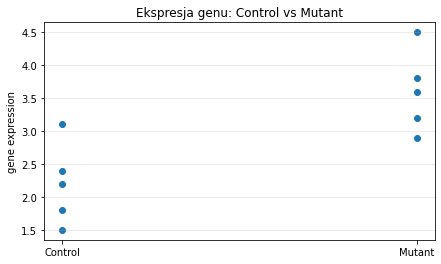

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
x_positions = np.where(df['genotype'].eq('Control'), 0, 1)
ax.scatter(x_positions, df['gene_expression'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Mutant'])
ax.set_ylabel('gene expression')
ax.set_title('Ekspresja genu: Control vs Mutant')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

## 2. Funkcja do dopasowania modelu liniowego

Dla dowolnej macierzy $X$ policzymy:

- współczynniki $\hat\beta$,
- predykcje $\hat y = X\hat\beta$,
- reszty $e_i = y_i - \hat y_i$,
- sumę kwadratów reszt $SSE = \sum_i e_i^2$,
- błędy standardowe współczynników.

W tym notebooku liczba parametrów to liczba kolumn w $X$. Dla modeli pełnego rzędu stopnie swobody reszt to:

$$
df_{resid} = n-k
$$

czyli liczba obserwacji minus liczba parametrów.

In [5]:
def fit_ols(X, y, column_names=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    beta, residuals_raw, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    residuals = y - y_hat
    sse = float(residuals @ residuals)
    df_resid = n - rank
    mse = sse / df_resid
    xtx_inv = np.linalg.pinv(X.T @ X)
    cov_beta = mse * xtx_inv
    se_beta = np.sqrt(np.diag(cov_beta))
    t_values = beta / se_beta
    p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid)
    if column_names is None:
        column_names = [f'beta_{j}' for j in range(k)]
    coef_table = pd.DataFrame({
        'coef': beta,
        'std_error': se_beta,
        't': t_values,
        'p_value': p_values,
    }, index=column_names)
    return {
        'beta': beta,
        'y_hat': y_hat,
        'residuals': residuals,
        'sse': sse,
        'rank': rank,
        'df_resid': df_resid,
        'mse': mse,
        'cov_beta': cov_beta,
        'coef_table': coef_table,
    }


def compare_nested_models(sse_reduced, k_reduced, sse_full, k_full, n):
    """Partial F-test for nested linear models."""
    df_num = k_full - k_reduced
    df_den = n - k_full
    ms_added = (sse_reduced - sse_full) / df_num
    ms_error = sse_full / df_den
    F = ms_added / ms_error
    p = f.sf(F, df_num, df_den)
    return pd.Series({
        'SSE_reduced': sse_reduced,
        'SSE_full': sse_full,
        'df_num': df_num,
        'df_den': df_den,
        'F': F,
        'p_value': p,
    })

## 3. Model zerowy: jedna średnia dla wszystkich myszy

Najprostszy model ma tylko intercept. Design matrix ma jedną kolumnę samych jedynek:

$$
X_0 =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix}
$$

Model mówi: „nie patrzę na genotyp, przewiduję wszystkim tę samą wartość”. Tą wartością jest średnia ogólna.

In [6]:
y = df['gene_expression'].to_numpy()
X_null = np.ones((len(df), 1))
fit_null = fit_ols(X_null, y, ['grand_mean'])
fit_null['coef_table']

,coef,std_error,t,p_value
grand_mean,2.9,0.296273,9.788265,0.000004


In [7]:
pd.DataFrame({
    'mouse_id': df['mouse_id'],
    'genotype': df['genotype'],
    'y': y,
    'y_hat_null': fit_null['y_hat'],
    'residual_null': fit_null['residuals'],
})

,mouse_id,genotype,y,y_hat_null,residual_null
0,C1,Control,1.5,2.9,-1.4
1,C2,Control,1.8,2.9,-1.1
2,C3,Control,2.2,2.9,-0.7
3,C4,Control,2.4,2.9,-0.5
4,C5,Control,3.1,2.9,0.2
5,M1,Mutant,2.9,2.9,0.0
6,M2,Mutant,3.2,2.9,0.3
7,M3,Mutant,3.6,2.9,0.7
8,M4,Mutant,3.8,2.9,0.9
9,M5,Mutant,4.5,2.9,1.6


In [8]:
fit_null['sse']

7.9

## 4. t-test jako model liniowy: dwie kolumny średnich grupowych

Teraz tworzymy macierz z dwiema kolumnami:

$$
X_{groups} =
\begin{bmatrix}
1 & 0 \\
1 & 0 \\
\vdots & \vdots \\
0 & 1 \\
0 & 1
\end{bmatrix}
$$

Pierwsza kolumna mówi: „ta obserwacja należy do Control”. Druga kolumna mówi: „ta obserwacja należy do Mutant”.

Model:

$$
\hat y_i = \beta_{Control}\cdot I(Control_i) + \beta_{Mutant}\cdot I(Mutant_i)
$$

Współczynniki są po prostu średnimi grupowymi.

In [9]:
X_group_means_df = pd.get_dummies(df['genotype']).astype(int)
X_group_means_df

,Control,Mutant
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [10]:
fit_group_means = fit_ols(X_group_means_df.to_numpy(), y, list(X_group_means_df.columns))
fit_group_means['coef_table']

,coef,std_error,t,p_value
Control,2.2,0.273861,8.033264,0.000042
Mutant,3.6,0.273861,13.145341,0.000001


In [11]:
pd.DataFrame({
    'mouse_id': df['mouse_id'],
    'genotype': df['genotype'],
    'y': y,
    'y_hat_group_model': fit_group_means['y_hat'],
    'residual_group_model': fit_group_means['residuals'],
})

,mouse_id,genotype,y,y_hat_group_model,residual_group_model
0,C1,Control,1.5,2.2,-7.000000e-01
1,C2,Control,1.8,2.2,-4.000000e-01
2,C3,Control,2.2,2.2,4.440892e-16
3,C4,Control,2.4,2.2,2.000000e-01
4,C5,Control,3.1,2.2,9.000000e-01
5,M1,Mutant,2.9,3.6,-7.000000e-01
6,M2,Mutant,3.2,3.6,-4.000000e-01
7,M3,Mutant,3.6,3.6,4.440892e-16
8,M4,Mutant,3.8,3.6,2.000000e-01
9,M5,Mutant,4.5,3.6,9.000000e-01


In [12]:
fit_group_means['sse']

3.0

## 5. To samo kodowanie: intercept + zmienna 0/1

Możemy zakodować ten sam model inaczej:

$$
X =
\begin{bmatrix}
1 & 0 \\
1 & 0 \\
\vdots & \vdots \\
1 & 1 \\
1 & 1
\end{bmatrix}
$$

Model:

$$
\hat y = \beta_0 + \beta_1 I(Mutant)
$$

Wtedy:

- $\beta_0$ to średnia dla `Control`,
- $\beta_1$ to różnica `Mutant - Control`.

To jest bardzo ważna intuicja: **współczynnik przy zmiennej 0/1 jest różnicą między grupami względem grupy referencyjnej**.

In [13]:
mutant_indicator = (df['genotype'] == 'Mutant').astype(int).to_numpy()
X_intercept_indicator = np.column_stack([np.ones(len(df)), mutant_indicator])
fit_indicator = fit_ols(X_intercept_indicator, y, ['intercept_Control_mean', 'Mutant_minus_Control'])
fit_indicator['coef_table']

,coef,std_error,t,p_value
intercept_Control_mean,2.2,0.273861,8.033264,0.000042
Mutant_minus_Control,1.4,0.387298,3.614784,0.006834


In [14]:
comparison = pd.DataFrame({
    'y_hat_group_means_coding': fit_group_means['y_hat'],
    'y_hat_intercept_indicator_coding': fit_indicator['y_hat'],
    'difference': fit_group_means['y_hat'] - fit_indicator['y_hat'],
})
comparison

,y_hat_group_means_coding,y_hat_intercept_indicator_coding,difference
0,2.2,2.2,-8.881784e-16
1,2.2,2.2,-8.881784e-16
2,2.2,2.2,-8.881784e-16
3,2.2,2.2,-8.881784e-16
4,2.2,2.2,-8.881784e-16
5,3.6,3.6,-1.776357e-15
6,3.6,3.6,-1.776357e-15
7,3.6,3.6,-1.776357e-15
8,3.6,3.6,-1.776357e-15
9,3.6,3.6,-1.776357e-15


## 6. Test F dla dwóch grup i związek $F=t^2$

Porównujemy dwa modele zagnieżdżone:

Model prostszy:

$$
y_i = \mu + \varepsilon_i
$$

Model pełniejszy:

$$
y_i = \mu + \delta I(Mutant_i) + \varepsilon_i
$$

Test F pyta:

> Czy dodatkowa kolumna `Mutant` zmniejszyła $SSE$ bardziej, niż spodziewalibyśmy się przez przypadek?

Wzór:

$$
F = \frac{(SSE_{reduced}-SSE_{full})/(k_{full}-k_{reduced})}{SSE_{full}/(n-k_{full})}
$$

Dla dwóch grup i klasycznego t-testu z założeniem wspólnej wariancji zachodzi:

$$
F = t^2
$$

In [15]:
F_table = compare_nested_models(
    sse_reduced=fit_null['sse'],
    k_reduced=1,
    sse_full=fit_indicator['sse'],
    k_full=2,
    n=len(df),
)
F_table

SSE_reduced     7.900000
SSE_full        3.000000
df_num          1.000000
df_den          8.000000
F              13.066667
p_value         0.006834
dtype: float64

In [16]:
control = df.loc[df['genotype'] == 'Control', 'gene_expression'].to_numpy()
mutant = df.loc[df['genotype'] == 'Mutant', 'gene_expression'].to_numpy()

n_control, n_mutant = len(control), len(mutant)
mean_control, mean_mutant = control.mean(), mutant.mean()
var_control, var_mutant = control.var(ddof=1), mutant.var(ddof=1)

pooled_var = ((n_control - 1)*var_control + (n_mutant - 1)*var_mutant) / (n_control + n_mutant - 2)
se_diff = np.sqrt(pooled_var * (1/n_control + 1/n_mutant))
t_stat = (mean_mutant - mean_control) / se_diff
df_t = n_control + n_mutant - 2
p_t = 2 * stats.t.sf(abs(t_stat), df_t)

pd.Series({
    'mean_Control': mean_control,
    'mean_Mutant': mean_mutant,
    'difference': mean_mutant - mean_control,
    'pooled_variance': pooled_var,
    'SE_difference': se_diff,
    't': t_stat,
    't^2': t_stat**2,
    'p_value_t_test': p_t,
    'F_from_model_comparison': F_table['F'],
    'p_value_F_test': F_table['p_value'],
})

mean_Control                2.200000
mean_Mutant                 3.600000
difference                  1.400000
pooled_variance             0.375000
SE_difference               0.387298
t                           3.614784
t^2                        13.066667
p_value_t_test              0.006834
F_from_model_comparison    13.066667
p_value_F_test              0.006834
dtype: float64

### Intuicja prowadzącego

- Model z jedną średnią ma dużą karę, bo ignoruje różnicę między grupami.
- Model z dwiema średnimi dopasowuje osobno `Control` i `Mutant`.
- Test F patrzy, czy zysk w $SSE$ jest duży względem szumu wewnątrz grup.
- Dla dwóch grup to jest dokładnie ta sama informacja co klasyczny t-test.

## 7. ANOVA jako model liniowy z wieloma kolumnami grupowymi

ANOVA to naturalne rozszerzenie tego samego pomysłu.

Jeśli mamy pięć grup, to tworzymy pięć kolumn one-hot:

$$
\hat y_i = \beta_A I(A_i) + \beta_B I(B_i) + \beta_C I(C_i) + \beta_D I(D_i) + \beta_E I(E_i)
$$

Każdy współczynnik jest średnią swojej grupy. Test F porównuje:

- model z jedną średnią ogólną,
- model z osobną średnią dla każdej grupy.

In [17]:
anova_df = pd.DataFrame({
    'group': ['A']*4 + ['B']*4 + ['C']*4 + ['D']*4 + ['E']*4,
    'gene_expression': [
        1.8, 2.0, 2.2, 2.4,
        2.1, 2.4, 2.7, 3.0,
        3.2, 3.4, 3.6, 3.8,
        4.2, 4.4, 4.6, 5.0,
        2.7, 3.1, 3.4, 3.7,
    ]
})

anova_df.groupby('group')['gene_expression'].agg(['count', 'mean', 'std'])

,count,mean,std
group,,,
A,4,2.100,0.258199
B,4,2.550,0.387298
C,4,3.500,0.258199
D,4,4.550,0.341565
E,4,3.225,0.427200


In [18]:
y_anova = anova_df['gene_expression'].to_numpy()
X_anova_null = np.ones((len(anova_df), 1))
X_anova_groups_df = pd.get_dummies(anova_df['group']).astype(int)

fit_anova_null = fit_ols(X_anova_null, y_anova, ['grand_mean'])
fit_anova_groups = fit_ols(X_anova_groups_df.to_numpy(), y_anova, list(X_anova_groups_df.columns))

anova_F_table = compare_nested_models(
    sse_reduced=fit_anova_null['sse'],
    k_reduced=1,
    sse_full=fit_anova_groups['sse'],
    k_full=X_anova_groups_df.shape[1],
    n=len(anova_df),
)

anova_F_table

SSE_reduced    1.592550e+01
SSE_full       1.747500e+00
df_num         4.000000e+00
df_den         1.500000e+01
F              3.042489e+01
p_value        4.871065e-07
dtype: float64

In [19]:
# Porównanie z gotową funkcją scipy.stats.f_oneway.
groups = [g['gene_expression'].to_numpy() for _, g in anova_df.groupby('group')]
scipy_F, scipy_p = stats.f_oneway(*groups)
pd.Series({'F_manual': anova_F_table['F'], 'p_manual': anova_F_table['p_value'], 'F_scipy': scipy_F, 'p_scipy': scipy_p})

F_manual    3.042489e+01
p_manual    4.871065e-07
F_scipy     3.042489e+01
p_scipy     4.871065e-07
dtype: float64

## 8. Regresja z cechą ciągłą i grupą: `expression ~ weight + genotype`

To jest przejście z „czystej ANOVA” do klasycznej regresji z kilkoma predyktorami.

Model:

$$
\widehat{expression} = \beta_0 + \beta_1 \cdot weight + \beta_2 \cdot I(Mutant)
$$

Interpretacja:

- $\beta_1$: jak zmienia się ekspresja przy wzroście masy o 1 jednostkę,
- $\beta_2$: różnica Mutant vs Control **po uwzględnieniu masy**.

To jest świetny moment dydaktyczny: design matrix pozwala łączyć zmienne ciągłe i kategoryczne w jednym modelu.

In [20]:
weight_df = pd.DataFrame({
    'weight': [18,19,20,21,22,23,24,25, 18,19,20,21,22,23,24,25],
    'genotype': ['Control']*8 + ['Mutant']*8,
    'gene_expression': [2.1,2.3,2.5,2.6,2.8,3.0,3.1,3.3, 2.8,2.9,3.2,3.3,3.6,3.7,4.0,4.1]
})
weight_df['Mutant'] = (weight_df['genotype'] == 'Mutant').astype(int)
weight_df

,weight,genotype,gene_expression,Mutant
0,18,Control,2.1,0
1,19,Control,2.3,0
2,20,Control,2.5,0
3,21,Control,2.6,0
4,22,Control,2.8,0
5,23,Control,3.0,0
6,24,Control,3.1,0
7,25,Control,3.3,0
8,18,Mutant,2.8,1
9,19,Mutant,2.9,1


In [21]:
y_w = weight_df['gene_expression'].to_numpy()
X_weight_only = np.column_stack([np.ones(len(weight_df)), weight_df['weight'].to_numpy()])
X_weight_genotype = np.column_stack([np.ones(len(weight_df)), weight_df['weight'].to_numpy(), weight_df['Mutant'].to_numpy()])

fit_weight_only = fit_ols(X_weight_only, y_w, ['intercept', 'weight'])
fit_weight_genotype = fit_ols(X_weight_genotype, y_w, ['intercept', 'weight', 'Mutant'])

fit_weight_genotype['coef_table']

,coef,std_error,t,p_value
intercept,-1.190774,0.131838,-9.032095,5.783549e-07
weight,0.181548,0.006064,29.940948,2.227765e-13
Mutant,0.737500,0.027787,26.541616,1.042365e-12


In [22]:
partial_F_genotype = compare_nested_models(
    sse_reduced=fit_weight_only['sse'],
    k_reduced=2,
    sse_full=fit_weight_genotype['sse'],
    k_full=3,
    n=len(weight_df),
)
partial_F_genotype

SSE_reduced    2.215774e+00
SSE_full       4.014881e-02
df_num         1.000000e+00
df_den         1.300000e+01
F              7.044574e+02
p_value        1.042365e-12
dtype: float64

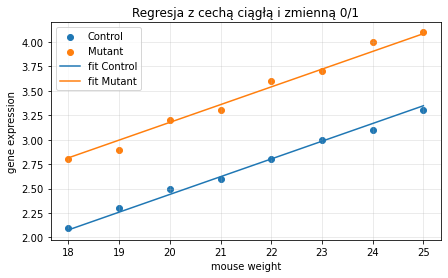

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
for genotype, group in weight_df.groupby('genotype'):
    ax.scatter(group['weight'], group['gene_expression'], label=genotype)

x_grid = np.linspace(weight_df['weight'].min(), weight_df['weight'].max(), 100)
beta = fit_weight_genotype['beta']
ax.plot(x_grid, beta[0] + beta[1]*x_grid + beta[2]*0, label='fit Control')
ax.plot(x_grid, beta[0] + beta[1]*x_grid + beta[2]*1, label='fit Mutant')
ax.set_xlabel('mouse weight')
ax.set_ylabel('gene expression')
ax.set_title('Regresja z cechą ciągłą i zmienną 0/1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 9. Krótkie ćwiczenia na wykładzie

### Ćwiczenie A: predykcja z macierzy

Dla modelu:

$$
\hat y = 1.0 + 0.1\cdot weight + 0.7\cdot I(Mutant)
$$

policz predykcję dla myszy `Mutant` o masie $20$.

**Odpowiedź:**

$$
\hat y = 1.0 + 0.1\cdot 20 + 0.7\cdot 1 = 3.7
$$

### Ćwiczenie B: co oznacza kolumna `Mutant`?

W modelu z interceptem i kolumną `Mutant`, współczynnik przy `Mutant` oznacza różnicę względem grupy referencyjnej, czyli `Control`.

### Ćwiczenie C: kiedy ANOVA jest regresją?

Gdy zmienną kategoryczną kodujemy przez kolumny one-hot. Wtedy regresja liniowa z tymi kolumnami estymuje średnie grupowe.

## 10. Checklista prowadzącego

Po tym notebooku student powinien umieć powiedzieć:

1. Co to jest design matrix.
2. Dlaczego intercept to kolumna jedynek.
3. Dlaczego t-test można zapisać jako regresję z predyktorem 0/1.
4. Dlaczego ANOVA to regresja z wieloma kolumnami one-hot.
5. Skąd bierze się test F dla porównania modeli.
6. Dlaczego dla dwóch grup zachodzi $F=t^2$.